# CHMv2 Model Inference

### Setup

In [ ]:
import io
import sys
import urllib

import matplotlib.pyplot as plt
import rasterio

import torch
import torch.nn.functional as F
from torchvision.transforms import v2
from tqdm import tqdm


# Set the DINOv3 repo location
DINOV3_LOCATION = "/PATH/TO/DINOV3/REPO"
print(f"DINOv3 location set to {DINOV3_LOCATION}")

sys.path.append(DINOV3_LOCATION)

### Model Loading
We load the DINOv3 ViT-L satellite model and the corresponding CHMv2 decoder.

In [2]:
from dinov3.hub.backbones import Weights

chmv2_model = torch.hub.load(
    DINOV3_LOCATION,
    'dinov3_vitl16_chmv2',
    source="local",
    weights="<CHMV2_MODEL/CHECKPOINT/URL/OR/PATH>",
    backbone_weights=Weights.SAT493M,  # or <DINOV3_VITL_SAT/CHECKPOINT/URL/OR/PATH>
)
chmv2_model.cuda().eval()

Backbone does not define embed_dims, using [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024] instead
Backbone does not define input_pad_size, using patch_size=16 instead


Depther(
  (encoder): DinoVisionTransformerWrapper(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (rope_embed): RopePositionEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x SelfAttentionBlock(
          (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): SelfAttention(
            (qkv): LinearKMaskedBias(in_features=1024, out_features=3072, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linea

### Data Loading
Now that we have the model set up, let's load the data

In [3]:
# Using test samples from the NEON dataset that can be downloaded following instructions in
# https://github.com/facebookresearch/HighResCanopyHeight
# Original dataset: National Ecological Observatory Network (NEON), 2022. Ecosystem Structure
# URL: https://data.neonscience.org/data-products/DP3.30015.001.
neon_images_uri = [
    "https://dl.fbaipublicfiles.com/dinov3/notebooks/chmv2/2017_WLOU_1_NEON_D13_WLOU_DP3_419000_4416000_RGB.tif_1_1.tif",
    "https://dl.fbaipublicfiles.com/dinov3/notebooks/chmv2/2018_GUAN_1_NEON_D04_GUAN_DP3_725000_1985000_RGB.tif_2_1.tif",
    "https://dl.fbaipublicfiles.com/dinov3/notebooks/chmv2/2019_HOPB_3_NEON_D01_HOPB_DP3_717000_4705000_RGB.tif_1_1.tif",
    "https://dl.fbaipublicfiles.com/dinov3/notebooks/chmv2/2019_REDB_2_NEON_D15_REDB_DP3_433000_4516000_RGB.tif_2_2.tif",
    "https://dl.fbaipublicfiles.com/dinov3/notebooks/chmv2/2019_WLOU_2_NEON_D13_WLOU_DP3_420000_4417000_RGB.tif_0_0.tif",

]
neon_images_list = []


def load_image_as_tensor(uri: str) -> torch.Tensor:
    """Load a rasterio image from URI as a PyTorch tensor."""
    with urllib.request.urlopen(uri) as response:
        data = response.read()
    with rasterio.open(io.BytesIO(data)) as src:
        img = src.read()
        return torch.from_numpy(img)

for neon_image_uri in neon_images_uri:
    neon_images_list.append(load_image_as_tensor(neon_image_uri))

### Data Transforms

In [4]:
CHMV2_MEAN = (0.420, 0.411, 0.296)
CHMV2_STD = (0.213, 0.156, 0.143)

def make_transform():
    to_tensor = v2.ToImage()
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(mean=CHMV2_MEAN, std=CHMV2_STD)
    return v2.Compose([to_tensor, to_float, normalize])

### Producing the canopy height map

In [5]:
image_transform = make_transform()

canopy_height_results = []
with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        for image in tqdm(neon_images_list, desc="Processing images"):
            image_processed = image_transform(image)
            pred = chmv2_model(image_processed.unsqueeze(0).cuda())
            pred_resized = F.interpolate(pred, size=image.shape[-2:], mode='bilinear', align_corners=False)
            canopy_height_results.append(pred_resized.squeeze().cpu())


Processing images: 100%|██████████| 5/5 [00:00<00:00,  7.21it/s]


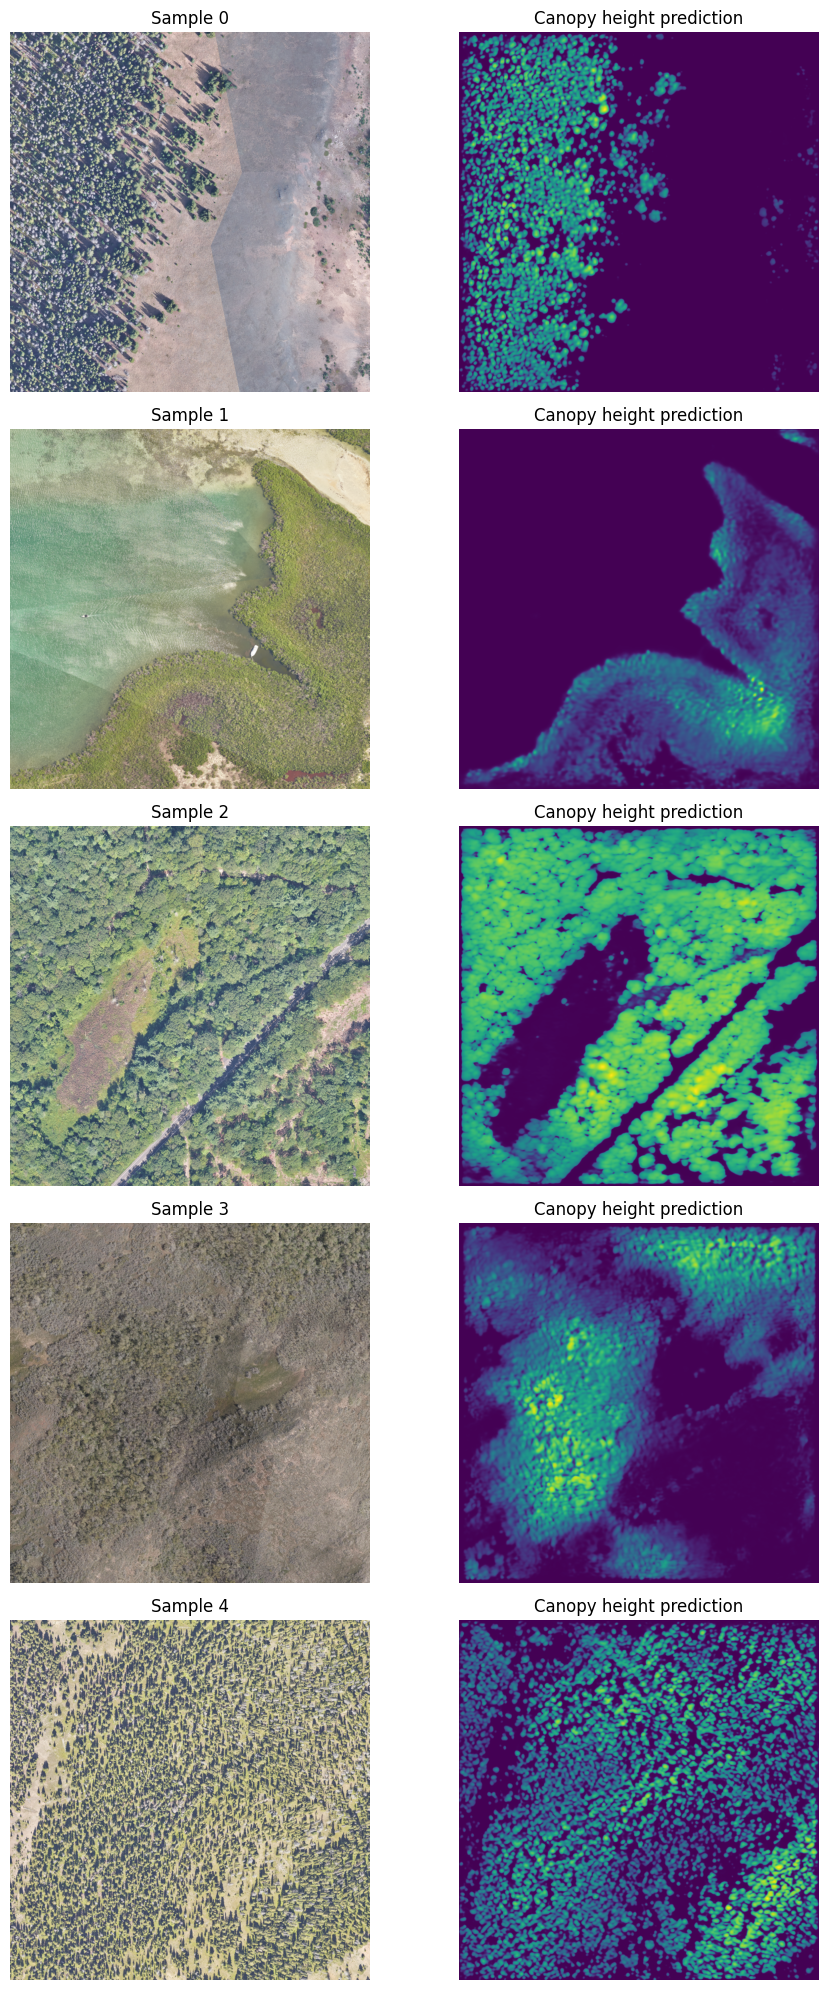

In [6]:
n = len(canopy_height_results)
fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

for i, res in enumerate(canopy_height_results):
    axes[i, 0].imshow(neon_images_list[i].permute(1, 2, 0))
    axes[i, 0].set_title(f"Sample {i}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(canopy_height_results[i], cmap='viridis')
    axes[i, 1].set_title("Canopy height prediction")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()
